# Clean predictive price-change game

This notebook is a report-ready version of the predictive airline pricing game.

It uses a **price-change strategy** instead of a price-level strategy:

- `Increase`: the carrier's passenger-weighted fare increased relative to the previous quarter;
- `Decrease`: the carrier's passenger-weighted fare did not increase.

The model is estimated on 2021–2023 data and evaluated on 2024 data. No intermediate CSV or PNG files are saved; all outputs are displayed in the notebook.


In [1]:
from pathlib import Path
import warnings

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# Robust project-root detection: works from repository root, HW_2/, or HW_2/notebooks/.
CURRENT_DIR = Path.cwd().resolve()
if (CURRENT_DIR / "HW_2").exists():
    HW2_DIR = CURRENT_DIR / "HW_2"
elif CURRENT_DIR.name == "HW_2":
    HW2_DIR = CURRENT_DIR
elif CURRENT_DIR.parent.name == "HW_2":
    HW2_DIR = CURRENT_DIR.parent
else:
    HW2_DIR = CURRENT_DIR

DATA_DIR = HW2_DIR / "data"
CACHE_DIR = HW2_DIR / "cache"
COMBINED_PARQUET = CACHE_DIR / "db1b_market_combined.parquet"
assert COMBINED_PARQUET.exists(), f"Missing {COMBINED_PARQUET}. Run 01_db1b_market_eda.ipynb first."

TOP_N_ROUTES = 50
MIN_ROUTE_TRAIN_PASSENGERS = 50_000
MIN_TRAIN_ACTIVE_QUARTERS = 10
MIN_TEST_ACTIVE_QUARTERS = 3
FARE_MIN = 20
FARE_MAX = 1000
TRAIN_END_YEAR = 2023
TEST_YEAR = 2024
PRICE_CHANGE_THRESHOLD = 0.0

STRATEGIES = ["Decrease", "Increase"]
PROFILES = [
    ("Decrease", "Decrease"),
    ("Decrease", "Increase"),
    ("Increase", "Decrease"),
    ("Increase", "Increase"),
]

print(f"Data: {COMBINED_PARQUET}")
print(f"Fare filter: {FARE_MIN} <= MARKET_FARE <= {FARE_MAX}")
print("Train: 2021Q2–2023Q4; Test: 2024Q1–2024Q4")


Data: /Users/tsarikov-i-i/4_Game_Theory&Decision_Making/HW_2/cache/db1b_market_combined.parquet
Fare filter: 20 <= MARKET_FARE <= 1000
Train: 2021Q2–2023Q4; Test: 2024Q1–2024Q4


## 1. Model specification

Players are route-level roles:

- `Leader`: largest carrier on a route in the training period;
- `Challenger`: second-largest carrier on the same route in the training period.

Strategies:

\[
s_{i,r,t}=\begin{cases}
Increase, & \frac{p_{i,r,t}}{p_{i,r,t-1}} - 1 > 0,\\
Decrease, & \frac{p_{i,r,t}}{p_{i,r,t-1}} - 1 \le 0.
\end{cases}
\]

Payoffs are normalized revenues:

\[
u_{i,r,t}=\frac{Revenue_{i,r,t}}{\overline{Revenue}_{i,r,train}}.
\]

This normalization makes routes of different sizes comparable in one pooled game.


## 2. Data preparation and route selection

The route and player selection is based only on training data to avoid test leakage.


In [2]:
con = duckdb.connect(database=":memory:")
con.execute("PRAGMA threads=4")
con.execute("PRAGMA memory_limit='8GB'")

# Aggregate raw filtered data to route-carrier-quarter level.
con.execute(f"""
CREATE OR REPLACE TABLE rcq AS
SELECT
    route_airport,
    period,
    year,
    quarter,
    carrier,
    SUM(passengers) AS passengers,
    SUM(ticket_revenue_proxy) AS revenue_proxy,
    SUM(ticket_revenue_proxy) / NULLIF(SUM(passengers), 0) AS avg_fare_weighted
FROM read_parquet('{COMBINED_PARQUET}')
WHERE market_fare BETWEEN {FARE_MIN} AND {FARE_MAX}
  AND passengers > 0
GROUP BY 1, 2, 3, 4, 5
""")

selected_routes = con.execute(f"""
WITH train AS (
    SELECT * FROM rcq WHERE year <= {TRAIN_END_YEAR}
), route_carrier AS (
    SELECT
        route_airport,
        carrier,
        SUM(passengers) AS train_passengers,
        COUNT(DISTINCT period) AS train_active_quarters
    FROM train
    GROUP BY 1, 2
), ranked AS (
    SELECT
        *,
        SUM(train_passengers) OVER (PARTITION BY route_airport) AS route_train_passengers,
        ROW_NUMBER() OVER (PARTITION BY route_airport ORDER BY train_passengers DESC) AS carrier_rank
    FROM route_carrier
), top2 AS (
    SELECT
        route_airport,
        MAX(route_train_passengers) AS route_train_passengers,
        MAX(CASE WHEN carrier_rank = 1 THEN carrier END) AS leader,
        MAX(CASE WHEN carrier_rank = 2 THEN carrier END) AS challenger,
        MAX(CASE WHEN carrier_rank = 1 THEN train_passengers END) AS leader_train_passengers,
        MAX(CASE WHEN carrier_rank = 2 THEN train_passengers END) AS challenger_train_passengers,
        MAX(CASE WHEN carrier_rank = 1 THEN train_active_quarters END) AS leader_train_active_quarters,
        MAX(CASE WHEN carrier_rank = 2 THEN train_active_quarters END) AS challenger_train_active_quarters
    FROM ranked
    GROUP BY 1
), test_activity AS (
    SELECT route_airport, carrier, COUNT(DISTINCT period) AS test_active_quarters
    FROM rcq
    WHERE year = {TEST_YEAR}
    GROUP BY 1, 2
), selected AS (
    SELECT
        t.*,
        COALESCE(ta.test_active_quarters, 0) AS leader_test_active_quarters,
        COALESCE(tb.test_active_quarters, 0) AS challenger_test_active_quarters,
        leader_train_passengers / NULLIF(route_train_passengers, 0) AS leader_train_share,
        challenger_train_passengers / NULLIF(route_train_passengers, 0) AS challenger_train_share,
        (leader_train_passengers + challenger_train_passengers) / NULLIF(route_train_passengers, 0) AS top2_train_share
    FROM top2 t
    LEFT JOIN test_activity ta
      ON t.route_airport = ta.route_airport AND t.leader = ta.carrier
    LEFT JOIN test_activity tb
      ON t.route_airport = tb.route_airport AND t.challenger = tb.carrier
    WHERE challenger IS NOT NULL
      AND route_train_passengers >= {MIN_ROUTE_TRAIN_PASSENGERS}
      AND leader_train_active_quarters >= {MIN_TRAIN_ACTIVE_QUARTERS}
      AND challenger_train_active_quarters >= {MIN_TRAIN_ACTIVE_QUARTERS}
      AND COALESCE(ta.test_active_quarters, 0) >= {MIN_TEST_ACTIVE_QUARTERS}
      AND COALESCE(tb.test_active_quarters, 0) >= {MIN_TEST_ACTIVE_QUARTERS}
)
SELECT * FROM selected
ORDER BY route_train_passengers DESC
LIMIT {TOP_N_ROUTES}
""").df()

selection_summary = pd.DataFrame([
    {"Metric": "Selected routes", "Value": len(selected_routes)},
    {"Metric": "Total selected-route train passengers", "Value": selected_routes["route_train_passengers"].sum()},
    {"Metric": "Mean top-2 train share", "Value": selected_routes["top2_train_share"].mean()},
    {"Metric": "Minimum train active quarters per player", "Value": MIN_TRAIN_ACTIVE_QUARTERS},
    {"Metric": "Minimum test active quarters per player", "Value": MIN_TEST_ACTIVE_QUARTERS},
])

display(selection_summary)
display(selected_routes.head(10)[[
    "route_airport", "leader", "challenger", "route_train_passengers",
    "leader_train_share", "challenger_train_share", "top2_train_share"
]])


,Metric,Value
0,Selected routes,50.0000
1,Total selected-route train passengers,"16,565,767.0000"
2,Mean top-2 train share,0.7264
3,Minimum train active quarters per player,10.0000
4,Minimum test active quarters per player,3.0000


,route_airport,leader,challenger,route_train_passengers,leader_train_share,challenger_train_share,top2_train_share
0,JFK-LAX,DL,B6,"551,278.0000",0.3974,0.3663,0.7638
1,EWR-MCO,UA,B6,"491,107.0000",0.4671,0.2531,0.7202
2,MCO-SJU,B6,NK,"435,338.0000",0.2951,0.2511,0.5462
3,MCO-PHL,F9,AA,"433,177.0000",0.3550,0.3523,0.7073
4,LAX-SFO,UA,OO,"420,971.0000",0.2672,0.2327,0.4999
5,LGA-ORD,AA,UA,"420,799.0000",0.3871,0.2807,0.6679
6,LAX-ORD,UA,AA,"414,751.0000",0.4314,0.3596,0.7910
7,EWR-LAX,UA,B6,"398,513.0000",0.5502,0.1893,0.7394
8,JFK-SFO,DL,AS,"383,489.0000",0.3046,0.2834,0.5880
9,ATL-LGA,DL,WN,"382,157.0000",0.5496,0.1768,0.7264


## 3. Construct price-change game observations

The full internal panel contains technical variables, but the displayed table is intentionally compact and report-ready.


In [3]:
selected_values = ", ".join([f"('{r.route_airport}', '{r.leader}', '{r.challenger}')" for _, r in selected_routes.iterrows()])

panel_long = con.execute(f"""
WITH selected(route_airport, leader, challenger) AS (VALUES {selected_values}),
role_panel AS (
    SELECT
        r.route_airport,
        r.period,
        r.year,
        r.quarter,
        r.carrier,
        CASE
            WHEN r.carrier = s.leader THEN 'Leader'
            WHEN r.carrier = s.challenger THEN 'Challenger'
        END AS role,
        r.passengers,
        r.revenue_proxy,
        r.avg_fare_weighted,
        s.leader,
        s.challenger
    FROM rcq r
    JOIN selected s
      ON r.route_airport = s.route_airport
     AND r.carrier IN (s.leader, s.challenger)
)
SELECT * FROM role_panel
ORDER BY route_airport, role, year, quarter
""").df()

panel_long = panel_long.sort_values(["route_airport", "role", "year", "quarter"]).copy()
panel_long["prev_avg_fare_weighted"] = panel_long.groupby(["route_airport", "role"])["avg_fare_weighted"].shift(1)
panel_long["price_change_pct"] = panel_long["avg_fare_weighted"] / panel_long["prev_avg_fare_weighted"] - 1
panel_long["strategy"] = np.where(panel_long["price_change_pct"] > PRICE_CHANGE_THRESHOLD, "Increase", "Decrease")

train_means = (
    panel_long[(panel_long["year"] <= TRAIN_END_YEAR) & panel_long["price_change_pct"].notna()]
    .groupby(["route_airport", "role"], as_index=False)["revenue_proxy"]
    .mean()
    .rename(columns={"revenue_proxy": "train_mean_revenue"})
)
panel_long = panel_long.merge(train_means, on=["route_airport", "role"], how="left")
panel_long["payoff"] = panel_long["revenue_proxy"] / panel_long["train_mean_revenue"]

wide = panel_long.pivot_table(
    index=["route_airport", "period", "year", "quarter", "leader", "challenger"],
    columns="role",
    values=["price_change_pct", "strategy", "payoff"],
    aggfunc="first",
).reset_index()
wide.columns = ["_".join([str(x) for x in col if x]) if isinstance(col, tuple) else col for col in wide.columns]

game_panel = wide.dropna(subset=[
    "price_change_pct_Leader", "price_change_pct_Challenger",
    "payoff_Leader", "payoff_Challenger",
    "strategy_Leader", "strategy_Challenger",
]).copy()
game_panel["profile"] = game_panel["strategy_Leader"] + "-" + game_panel["strategy_Challenger"]
game_panel["sample"] = np.where(game_panel["year"] <= TRAIN_END_YEAR, "train", "test")

compact_panel = game_panel[[
    "route_airport", "period", "leader", "challenger",
    "price_change_pct_Leader", "price_change_pct_Challenger",
    "strategy_Leader", "strategy_Challenger",
    "payoff_Leader", "payoff_Challenger", "sample"
]].copy()

panel_summary = pd.DataFrame([
    {"Metric": "Train observations", "Value": int((game_panel["sample"] == "train").sum())},
    {"Metric": "Test observations", "Value": int((game_panel["sample"] == "test").sum())},
    {"Metric": "Routes", "Value": game_panel["route_airport"].nunique()},
])

display(panel_summary)
display(compact_panel.head(12))


,Metric,Value
0,Train observations,550
1,Test observations,200
2,Routes,50


,route_airport,period,leader,challenger,price_change_pct_Leader,price_change_pct_Challenger,strategy_Leader,strategy_Challenger,payoff_Leader,payoff_Challenger,sample
1,ATL-EWR,2021Q2,DL,UA,0.4002,0.6021,Increase,Increase,0.9411,0.1546,train
2,ATL-EWR,2021Q3,DL,UA,0.1632,0.0039,Increase,Increase,0.9589,0.5505,train
3,ATL-EWR,2021Q4,DL,UA,-0.1876,-0.2577,Decrease,Decrease,0.9605,0.5183,train
4,ATL-EWR,2022Q1,DL,UA,-0.1436,-0.0207,Decrease,Decrease,0.6054,0.3386,train
5,ATL-EWR,2022Q2,DL,UA,0.5650,0.4907,Increase,Increase,1.1347,1.1184,train
6,ATL-EWR,2022Q3,DL,UA,0.0772,0.0121,Increase,Increase,1.0670,1.2560,train
7,ATL-EWR,2022Q4,DL,UA,-0.0083,0.0314,Decrease,Increase,1.1880,1.4204,train
8,ATL-EWR,2023Q1,DL,UA,-0.1704,-0.1250,Decrease,Decrease,0.8158,1.0903,train
9,ATL-EWR,2023Q2,DL,UA,0.1253,0.0993,Increase,Increase,1.1903,1.5142,train
10,ATL-EWR,2023Q3,DL,UA,0.0266,-0.0122,Increase,Decrease,1.0643,1.5169,train


## 4. Training payoff matrix

The table below is the normal-form game. Rows are Leader strategies, columns are Challenger strategies. Each cell contains:

\[
(Leader\ payoff, Challenger\ payoff),\ n
\]

where payoffs are average normalized revenues in the training sample.


In [4]:
train_panel = game_panel.query("sample == 'train'").copy()
test_panel = game_panel.query("sample == 'test'").copy()

rows = []
for ls, cs in PROFILES:
    sub = train_panel[(train_panel["strategy_Leader"] == ls) & (train_panel["strategy_Challenger"] == cs)]
    rows.append({
        "leader_strategy": ls,
        "challenger_strategy": cs,
        "profile": f"{ls}-{cs}",
        "count": len(sub),
        "leader_payoff": sub["payoff_Leader"].mean(),
        "challenger_payoff": sub["payoff_Challenger"].mean(),
    })
train_payoff = pd.DataFrame(rows)

leader_mat = train_payoff.pivot(index="leader_strategy", columns="challenger_strategy", values="leader_payoff").reindex(index=STRATEGIES, columns=STRATEGIES)
challenger_mat = train_payoff.pivot(index="leader_strategy", columns="challenger_strategy", values="challenger_payoff").reindex(index=STRATEGIES, columns=STRATEGIES)
count_mat = train_payoff.pivot(index="leader_strategy", columns="challenger_strategy", values="count").reindex(index=STRATEGIES, columns=STRATEGIES)

payoff_bimatrix = pd.DataFrame(index=STRATEGIES, columns=STRATEGIES)
for ls in STRATEGIES:
    for cs in STRATEGIES:
        payoff_bimatrix.loc[ls, cs] = f"({leader_mat.loc[ls, cs]:.3f}, {challenger_mat.loc[ls, cs]:.3f}), n={int(count_mat.loc[ls, cs])}"

display(payoff_bimatrix)


,Decrease,Increase
Decrease,"(0.989, 0.967), n=162","(1.047, 1.040), n=39"
Increase,"(1.005, 1.018), n=68","(0.999, 1.009), n=281"


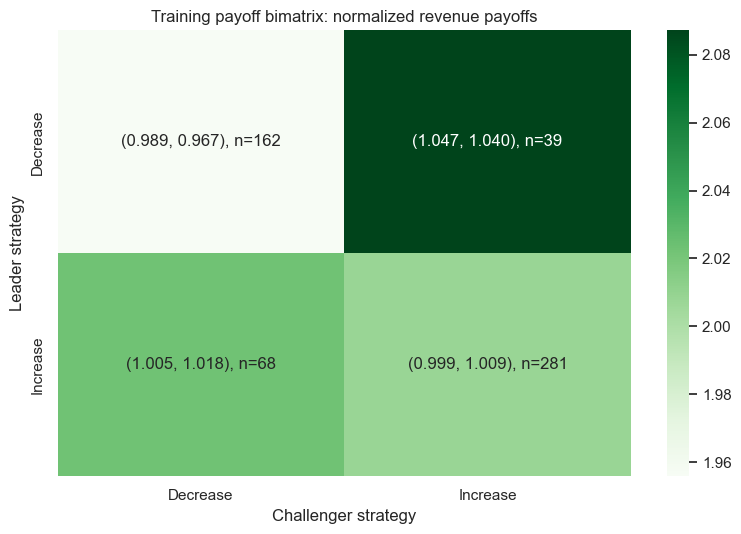

In [5]:
fig, ax = plt.subplots(figsize=(8, 5.5))
labels = payoff_bimatrix.copy()
sns.heatmap(leader_mat + challenger_mat, annot=labels, fmt="", cmap="Greens", cbar=True, ax=ax)
ax.set_title("Training payoff bimatrix: normalized revenue payoffs")
ax.set_xlabel("Challenger strategy")
ax.set_ylabel("Leader strategy")
plt.tight_layout()
plt.show()


## 5. Nash equilibrium from training data

Separate numerical matrices are used internally to compute best responses, but only compact best-response tables are displayed.


In [6]:
def compute_best_responses(leader_mat, challenger_mat):
    leader_rows = []
    challenger_rows = []
    best_leader = {}
    best_challenger = {}

    for cs in STRATEGIES:
        col = leader_mat[cs]
        best = set(col[col == col.max()].index)
        best_leader[cs] = best
        leader_rows.append({
            "If Challenger chooses": cs,
            "Leader best response": ", ".join(sorted(best)),
            "Leader payoff from best response": col.max(),
        })

    for ls in STRATEGIES:
        row = challenger_mat.loc[ls]
        best = set(row[row == row.max()].index)
        best_challenger[ls] = best
        challenger_rows.append({
            "If Leader chooses": ls,
            "Challenger best response": ", ".join(sorted(best)),
            "Challenger payoff from best response": row.max(),
        })

    ne = []
    for ls, cs in PROFILES:
        if ls in best_leader[cs] and cs in best_challenger[ls]:
            ne.append((ls, cs))
    return pd.DataFrame(leader_rows), pd.DataFrame(challenger_rows), ne, best_leader, best_challenger

leader_br, challenger_br, pure_ne, best_leader, best_challenger = compute_best_responses(leader_mat, challenger_mat)

display(leader_br)
display(challenger_br)

ne_text = "; ".join([f"({a}, {b})" for a, b in pure_ne])
pd.DataFrame([
    {"Result": "Pure Nash equilibrium/equilibria", "Value": ne_text},
    {"Result": "Minimum training cell count", "Value": int(count_mat.min().min())},
])


,If Challenger chooses,Leader best response,Leader payoff from best response
0,Decrease,Increase,1.0050
1,Increase,Decrease,1.0471


,If Leader chooses,Challenger best response,Challenger payoff from best response
0,Decrease,Increase,1.0402
1,Increase,Decrease,1.0176


,Result,Value
0,Pure Nash equilibrium/equilibria,"(Decrease, Increase); (Increase, Decrease)"
1,Minimum training cell count,39


## 6. Out-of-sample comparison with 2024

The theoretical prediction is the Nash equilibrium estimated from 2021–2023 data. We compare it with observed strategy profiles in 2024.


In [7]:
ne_profiles = {f"{a}-{b}" for a, b in pure_ne}

def profile_distribution(panel, name):
    dist = panel["profile"].value_counts(normalize=True).rename(name).reset_index()
    dist.columns = ["profile", name]
    return dist

profile_dist = pd.DataFrame({"profile": [f"{a}-{b}" for a, b in PROFILES]})
profile_dist = profile_dist.merge(profile_distribution(train_panel, "train_share"), on="profile", how="left")
profile_dist = profile_dist.merge(profile_distribution(test_panel, "test_share"), on="profile", how="left")
profile_dist = profile_dist.fillna(0)
profile_dist["predicted_NE"] = np.where(profile_dist["profile"].isin(ne_profiles), "yes", "no")

test_ne_match = test_panel["profile"].isin(ne_profiles).mean()
comparison_summary = pd.DataFrame([
    {"Metric": "Predicted NE profile(s)", "Value": "; ".join(sorted(ne_profiles))},
    {"Metric": "Test observations", "Value": len(test_panel)},
    {"Metric": "2024 share matching predicted NE", "Value": test_ne_match},
])

display(comparison_summary)
display(profile_dist)


,Metric,Value
0,Predicted NE profile(s),Decrease-Increase; Increase-Decrease
1,Test observations,200
2,2024 share matching predicted NE,0.2250


,profile,train_share,test_share,predicted_NE
0,Decrease-Decrease,0.2945,0.3750,no
1,Decrease-Increase,0.0709,0.1000,yes
2,Increase-Decrease,0.1236,0.1250,yes
3,Increase-Increase,0.5109,0.4000,no


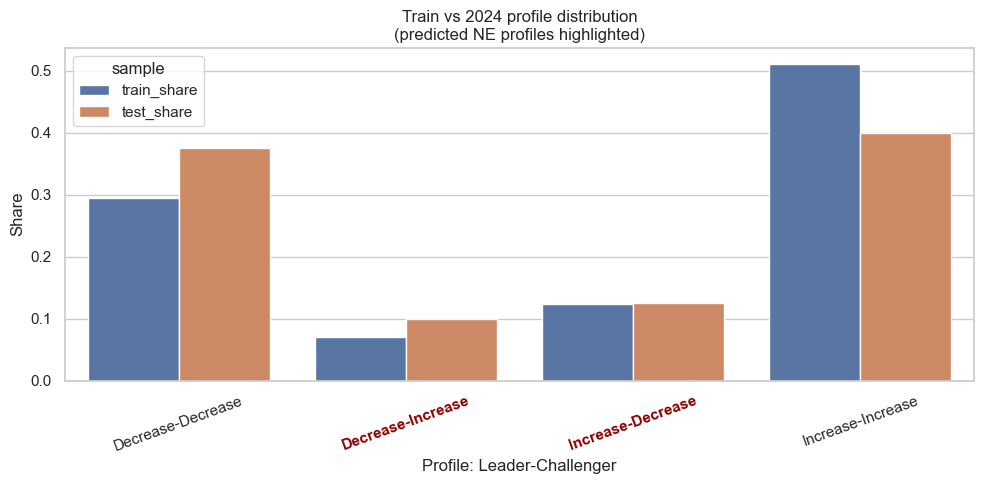

In [8]:
plot_df = profile_dist.melt(
    id_vars=["profile", "predicted_NE"],
    value_vars=["train_share", "test_share"],
    var_name="sample",
    value_name="share",
)
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=plot_df, x="profile", y="share", hue="sample", ax=ax)
for label in ax.get_xticklabels():
    if label.get_text() in ne_profiles:
        label.set_fontweight("bold")
        label.set_color("darkred")
ax.set_title("Train vs 2024 profile distribution\n(predicted NE profiles highlighted)")
ax.set_xlabel("Profile: Leader-Challenger")
ax.set_ylabel("Share")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()


## 7. Main empirical deviation: synchronized price movements

The Nash equilibrium predicts **asymmetric** price changes:

- `Decrease-Increase`;
- `Increase-Decrease`.

However, most observed profiles are synchronized:

- `Decrease-Decrease`;
- `Increase-Increase`.

This is the central empirical deviation from the one-shot static game prediction.


,Sample,Synchronized share,Asymmetric / NE-candidate share
0,Train 2021–2023,0.8055,0.1945
1,Test 2024,0.7750,0.2250


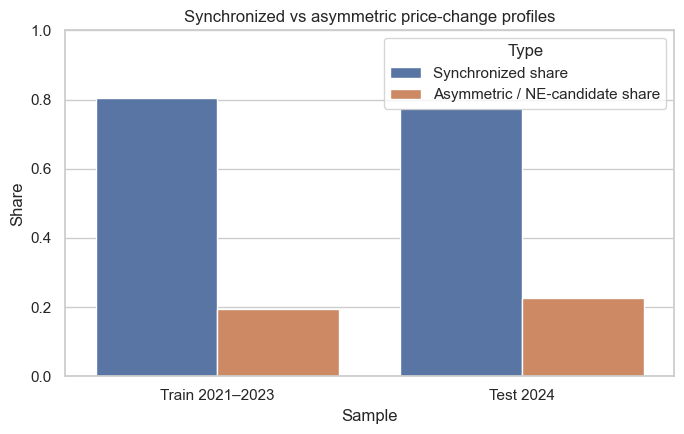

In [9]:
def synchronized_share(panel):
    return panel["profile"].isin(["Decrease-Decrease", "Increase-Increase"]).mean()

sync_summary = pd.DataFrame([
    {"Sample": "Train 2021–2023", "Synchronized share": synchronized_share(train_panel), "Asymmetric / NE-candidate share": 1 - synchronized_share(train_panel)},
    {"Sample": "Test 2024", "Synchronized share": synchronized_share(test_panel), "Asymmetric / NE-candidate share": 1 - synchronized_share(test_panel)},
])
display(sync_summary)

fig, ax = plt.subplots(figsize=(7, 4.5))
sync_plot = sync_summary.melt(id_vars="Sample", var_name="Type", value_name="Share")
sns.barplot(data=sync_plot, x="Sample", y="Share", hue="Type", ax=ax)
ax.set_ylim(0, 1)
ax.set_title("Synchronized vs asymmetric price-change profiles")
plt.tight_layout()
plt.show()


## 8. Role-level descriptive comparison

The previous version used player-level best-response consistency, but in this game the best-response structure is symmetric, so that metric is not informative for comparing Leader and Challenger.

Instead, we compare how often each role increases prices in train and test data.


,Role,Train Increase share,Test Increase share
0,Leader,0.6345,0.5250
1,Challenger,0.5818,0.5000


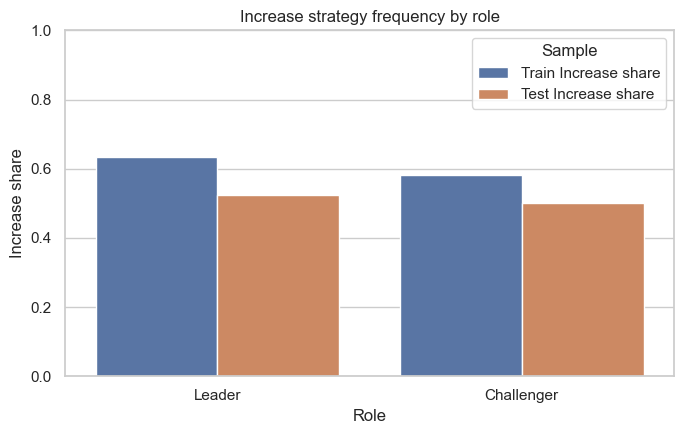

In [10]:
role_comparison = pd.DataFrame([
    {
        "Role": "Leader",
        "Train Increase share": (train_panel["strategy_Leader"] == "Increase").mean(),
        "Test Increase share": (test_panel["strategy_Leader"] == "Increase").mean(),
    },
    {
        "Role": "Challenger",
        "Train Increase share": (train_panel["strategy_Challenger"] == "Increase").mean(),
        "Test Increase share": (test_panel["strategy_Challenger"] == "Increase").mean(),
    },
])
display(role_comparison)

fig, ax = plt.subplots(figsize=(7, 4.5))
role_plot = role_comparison.melt(id_vars="Role", var_name="Sample", value_name="Increase share")
sns.barplot(data=role_plot, x="Role", y="Increase share", hue="Sample", ax=ax)
ax.set_ylim(0, 1)
ax.set_title("Increase strategy frequency by role")
plt.tight_layout()
plt.show()


## 9. Interpretation for the report

Main conclusions:

1. The model is predictive: the payoff matrix is estimated on 2021–2023 and evaluated on 2024.
2. The estimated static Nash equilibria are asymmetric profiles: `(Decrease, Increase)` and `(Increase, Decrease)`.
3. In 2024, only a minority of observations match these predicted NE profiles.
4. The dominant empirical pattern is synchronized price movement: both players increase or both decrease prices.
5. This suggests that a one-shot static game is too limited for airline pricing; common demand/cost shocks, seasonality, capacity constraints, and repeated interaction likely matter.
